# KNN Playlist Generator
**Purpose:** Given a playlist and n seed songs, generate a playlist using nearest neighbors. 

**Features:** BPM, Valence, Dance, Energy, Acoustic, Year, Popularity

**Steps:**
1. Select seed songs and map the feature space using K-means clustering and PCA.  
2. Pick k-nearest neighbors for each seed song to generate a playlist.

## Import Libraries

In [22]:
# Import necessary libraries for data analysis and visualization
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from itertools import combinations

## Read Data

In [8]:
df_playlist = pd.read_csv('../data/music_library.csv')
df_playlist

,#,Song,Artist,BPM,Camelot,Energy,Added At,Duration,Popularity,Genres,...,Valence,Speech,Live,Loud (Db),Key,Time Signature,Spotify Track Id,ISRC,Playlist,Album Year
0,1,When the Love is Gone,Des Rocs,141,9A,81,2026-03-05,03:20,52,NaN,...,47,0,20,-4,E Minor,4,5iRv1aH4eNai45KfhjtJ6n,USFYZ2557602,Rock,2026
1,2,BURNER PHONE,cleopatrick,136,9A,91,2026-03-05,03:21,42,NaN,...,46,0,30,-5,E Minor,4,1nUC2uuKUl49tDwQ1m4A1J,CAJXF2500023,Rock,2025
2,3,Queen Of Spades,Styx,135,12A,45,2026-03-05,05:41,36,"classic rock, aor, progressive rock",...,12,0,10,-13,C♯/D♭ Minor,4,54g63GAn77x9NcjiLzy7cW,USAM17802305,Rock,1978
3,4,Go Your Own Way,Fleetwood Mac,136,7B,81,2026-03-05,03:38,62,"yacht rock, classic rock, soft rock",...,82,0,10,-12,F Major,4,15rjQH7nTcTomKwfVMd4xl,USWB19900181,Rock,1988
4,5,I Don't Care Anymore - 2016 Remaster,Phil Collins,140,1B,42,2026-03-05,05:05,61,soft rock,...,44,0,0,-8,B Major,4,24IdPCimVnJJDRuB5YSDiS,USRH11509311,Rock,1982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,246,Not Like Us,Kendrick Lamar,101,3B,47,2026-03-10,04:34,88,"hip hop, west coast hip hop",...,21,0,10,-7,C♯/D♭ Major,4,6AI3ezQ4o3HUoP6Dhudph3,USUG12400910,Rap-R&B,2024
996,247,THANK GODDESS,Qveen Herby,106,8A,74,2026-03-11,02:47,52,NaN,...,38,10,0,-5,A Minor,4,27IubiEgQJczAE6OC7PgmQ,QZFZ62344251,Rap-R&B,2023
997,248,STUPID (feat. Yung Baby Tate),"Ashnikko,Baby Tate",150,10B,64,2026-03-11,02:47,65,NaN,...,54,10,0,-7,D Major,4,6qNB2ChCVPepl5ZjVJJTUW,GBAYE1900593,Rap-R&B,2019
998,249,HAHAHA,Lil Dicky,158,3B,49,2026-03-11,04:03,41,NaN,...,14,10,10,-7,C♯/D♭ Major,4,73cnzXHK8i4WC5Pw0ZIZ2F,QMRSZ2302742,Rap-R&B,2024


## Environment Variables

In [9]:
# === CONFIG ===
FEATURES = ['BPM', 'Dance', 'Energy', 'Valence', 'Acoustic']
METADATA = ['Song', 'Artist', 'Album', 'Playlist', 'Popularity', 'Album Date']

# Extract album year on the main df first
df_playlist['Album Year'] = df_playlist['Album Date'].str[:4].astype(int)

# Then slice
df_playlist_features = df_playlist[FEATURES]
df_playlist_metadata = df_playlist[METADATA + ['Album Year']]

# Verify
print(f"Songs: {len(df_playlist)}")
print(f"Features: {FEATURES}")
print(f"Missing features: {df_playlist[FEATURES].isna().sum().sum()}")
print(f"Missing album year: {df_playlist['Album Year'].isna().sum()}")

Songs: 1000
Features: ['BPM', 'Dance', 'Energy', 'Valence', 'Acoustic']
Missing features: 0
Missing album year: 0


## Generate Playlist

### 1. Select Seed Songs and Map Space

In [16]:
## == HELPER FUNCTIONS: SEED SONGS ===

# Collect seed songs into a DataFrame
def collect_seeds(df_playlist_metadata, df_playlist_features, seed_songs_dict):
    """
    Collect seed song data into a DataFrame.
    
    Parameters:
    - seed_songs_dict: dict of {song_name: artist_name}
    
    Returns:
    - df_seeds: DataFrame with song, artist, popularity, year, and FEATURES
    """
    seeds = []
    for song, artist in seed_songs_dict.items():
        result = get_song_features(df_playlist_metadata, df_playlist_features, song, artist)
        if result:
            seeds.append({
                'song': song,
                'artist': artist,
                'features': result['features'],
                'popularity': result['popularity'],
                'year': result['year']
            })
    
    df_seeds = pd.DataFrame(seeds)
    df_seeds[FEATURES] = pd.DataFrame(df_seeds['features'].tolist(), index=df_seeds.index)
    df_seeds = df_seeds.drop(columns=['features'])
    
    print("\n" + "="*50)
    print("SEED SUMMARY")
    print("="*50)
    print(df_seeds)
    
    return df_seeds

# Get song features
def get_song_features(df_playlist_metadata, df_playlist_features, song_name, artist_name=None):
    mask = df_playlist_metadata['Song'].str.contains(song_name, case=False, na=False)
    if artist_name:
        mask = mask & df_playlist_metadata['Artist'].str.contains(artist_name, case=False, na=False)
    
    if mask.sum() == 0:
        print(f"Couldn't find '{song_name}'" + (f" by '{artist_name}'" if artist_name else ""))
        return None
    
    idx = df_playlist_metadata[mask].index[0]
    meta = df_playlist_metadata.loc[idx]
    feats = df_playlist_features.loc[idx]
    
    print(f"{meta['Song']} — {meta['Artist']} ({meta['Album Year']})")
    print(f"  Popularity: {meta['Popularity']}")
    for feature in FEATURES:
        print(f"  {feature}: {feats[feature]}")
    
    return {
    'features': [int(feats[f]) for f in FEATURES],
    'popularity': int(meta['Popularity']),
    'year': int(meta['Album Year'])
    }

In [17]:
## == HELPER FUNCTIONS: PCA ===

def explore_pca(df_playlist_features):
    """Fit PCA on all components, plot variance explained, return scaler + pca."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_playlist_features)

    pca = PCA()
    pca.fit(X_scaled)
    var_explained = pca.explained_variance_ratio_
    cumulative = var_explained.cumsum()

    # Plot
    fig, ax = plt.subplots(figsize=(8, 5))
    x_pos = range(1, len(var_explained) + 1)
    ax.bar(x_pos, var_explained, alpha=0.7, label='Individual')
    ax.plot(x_pos, cumulative, 'ro-', label='Cumulative')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'PC{i}' for i in x_pos])
    ax.set_ylabel('Variance Explained')
    ax.set_xlabel('Principal Component')
    ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='90% threshold')
    ax.legend()
    ax.set_ylim(0, 1.05)
    plt.title('PCA Variance Explained')
    plt.tight_layout()
    plt.show()

    print("=" * 50)
    print("VARIANCE EXPLAINED")
    print("=" * 50)
    for i, (var, cum) in enumerate(zip(var_explained, cumulative)):
        print(f"PC{i+1}: {var:.1%} (cumulative: {cum:.1%})")

    return {
        'scaler': scaler,
        'pca': pca,
        'var_explained': var_explained,
        'cumulative': cumulative
    }


def visualize_seeds(df_playlist_features, df_seeds, variance_threshold=0.90):
    """
    Visualize seed placement in PCA space, using optimal n_components 
    from explore_pca (first k components that hit variance_threshold).
    """
    # --- PCA exploration: find optimal n_components ---
    pca_results = explore_pca(df_playlist_features)
    scaler = pca_results['scaler']
    X_scaled = scaler.transform(df_playlist_features)  # already fit, just transform

    n_components = int(np.argmax(pca_results['cumulative'] >= variance_threshold) + 1)
    print(f"\nUsing n_components={n_components} (explains "
          f"{pca_results['cumulative'][n_components - 1]:.1%} of variance)")

    # --- Refit PCA with optimal n_components ---
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    var_explained = pca.explained_variance_ratio_

    # --- Find best k ---
    def get_best_k(X_scaled, k_range=(3, 11)):
        scores = {}
        for k in range(k_range[0], k_range[1]):
            km = KMeans(n_clusters=k, n_init=50, random_state=42)
            labels = km.fit_predict(X_scaled)
            scores[k] = silhouette_score(X_scaled, labels)
        best_k = max(scores, key=scores.get)
        return best_k, scores

    best_k, scores = get_best_k(X_scaled)

    # --- Cluster ---
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)

    # --- Transform seeds ---
    seeds_scaled = scaler.transform(df_seeds[FEATURES])
    seeds_pca = pca.transform(seeds_scaled)
    seed_clusters = kmeans.predict(seeds_scaled)

    seed_distances = [
        np.linalg.norm(seeds_scaled[i] - kmeans.cluster_centers_[seed_clusters[i]])
        for i in range(len(seeds_scaled))
    ]

    # --- Plot: all pairwise PC combinations ---
    pairs = list(combinations(range(n_components), 2))
    n_plots = len(pairs)
    n_cols = min(3, n_plots)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()  # safe for both 1D and 2D layouts

    for ax, (i, j) in zip(axes, pairs):
        ax.scatter(X_pca[:, i], X_pca[:, j], c=clusters, cmap='viridis', alpha=0.5)
        ax.scatter(seeds_pca[:, i], seeds_pca[:, j],
                   c='red', s=150, edgecolors='black', linewidths=2, label='Seeds', zorder=5)
        for idx, row in df_seeds.iterrows():
            ax.annotate(row['song'], (seeds_pca[idx, i], seeds_pca[idx, j]),
                        fontsize=8, ha='left', va='bottom')
        ax.set_xlabel(f'PC{i+1} ({var_explained[i]:.1%})')
        ax.set_ylabel(f'PC{j+1} ({var_explained[j]:.1%})')

    axes[0].legend()

    # Hide any unused subplots
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    plt.suptitle(f'Seed Placement (k={best_k}, {n_components} PCs @ '
                 f'{variance_threshold:.0%} variance)', fontsize=14)
    plt.tight_layout()
    plt.show()

    # --- Print summary ---
    print(f"\nBest k: {best_k} (silhouette: {scores[best_k]:.3f})")
    print("\nSEED CLUSTER ASSIGNMENTS")
    print("=" * 50)
    for idx, row in df_seeds.iterrows():
        print(f"{row['song']} → Cluster {seed_clusters[idx]} "
              f"(distance: {seed_distances[idx]:.2f})")

    return {
        'kmeans': kmeans,
        'scaler': scaler,
        'pca': pca,
        'clusters': clusters,
        'best_k': best_k,
        'n_components': n_components
    }

Can't C Me — 2Pac (1996)
  Popularity: 70
  BPM: 95
  Dance: 80
  Energy: 85
  Valence: 67
  Acoustic: 4
Forgot About Dre — Dr. Dre,Eminem (1999)
  Popularity: 80
  BPM: 134
  Dance: 92
  Energy: 74
  Valence: 62
  Acoustic: 8
Dance With Me — 112 (2001)
  Popularity: 66
  BPM: 102
  Dance: 91
  Energy: 51
  Valence: 61
  Acoustic: 3
HEATED — Beyoncé (2022)
  Popularity: 67
  BPM: 111
  Dance: 79
  Energy: 73
  Valence: 50
  Acoustic: 6
Tunnel Vision — Justin Timberlake (2013)
  Popularity: 52
  BPM: 142
  Dance: 57
  Energy: 77
  Valence: 57
  Acoustic: 28

SEED SUMMARY
               song             artist  popularity  year  BPM  Dance  Energy  \
0        Can't C Me               2Pac          70  1996   95     80      85   
1  Forgot About Dre            Dr. Dre          80  1999  134     92      74   
2     Dance With Me                112          66  2001  102     91      51   
3            Heated            Beyoncé          67  2022  111     79      73   
4     Tunnel Vision  Ju

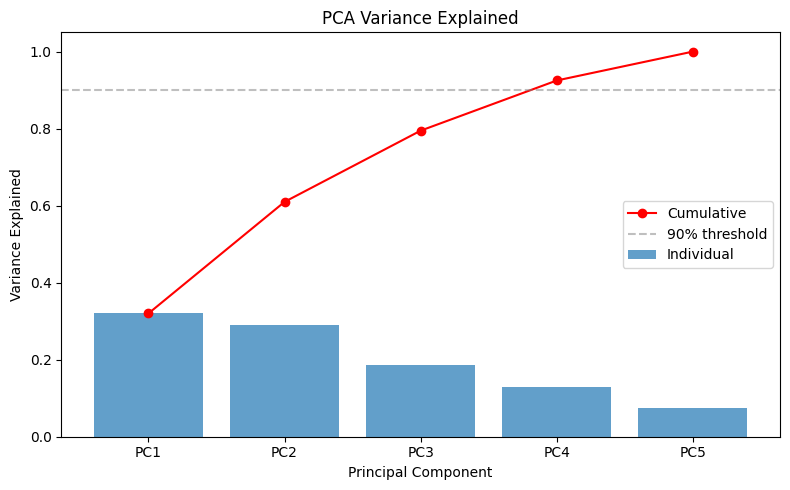

VARIANCE EXPLAINED
PC1: 32.0% (cumulative: 32.0%)
PC2: 29.0% (cumulative: 61.0%)
PC3: 18.5% (cumulative: 79.5%)
PC4: 13.0% (cumulative: 92.5%)
PC5: 7.5% (cumulative: 100.0%)

Using n_components=4 (explains 92.5% of variance)


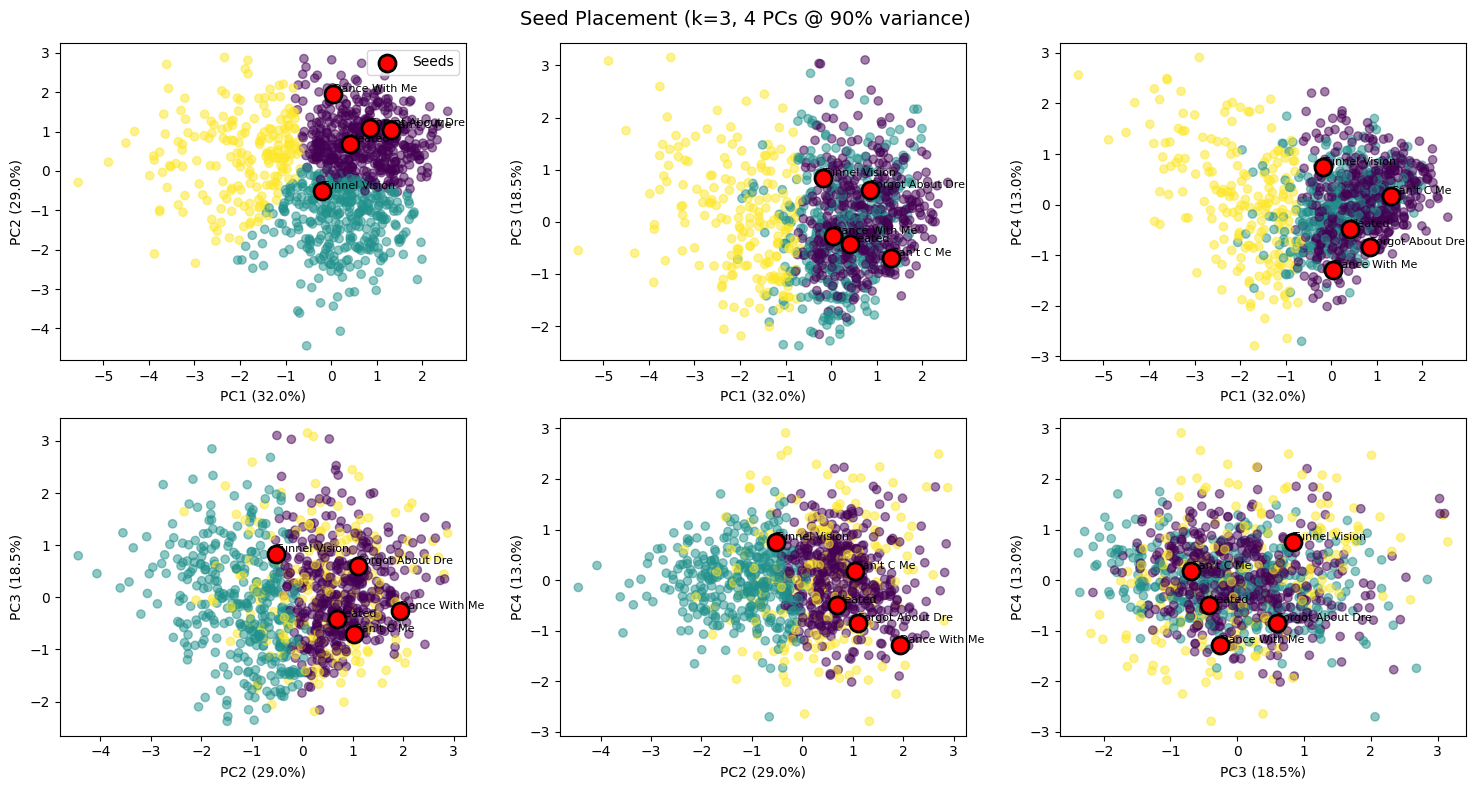


Best k: 3 (silhouette: 0.218)

SEED CLUSTER ASSIGNMENTS
Can't C Me → Cluster 0 (distance: 1.14)
Forgot About Dre → Cluster 0 (distance: 1.41)
Dance With Me → Cluster 0 (distance: 1.87)
Heated → Cluster 0 (distance: 0.93)
Tunnel Vision → Cluster 1 (distance: 1.47)


In [18]:
seed_songs_dict = {
    "Can't C Me": "2Pac",
    "Forgot About Dre": "Dr. Dre", 
    "Dance With Me": "112", 
    "Heated": "Beyoncé",
    "Tunnel Vision": "Justin Timberlake"
}

df_seeds = collect_seeds(df_playlist_metadata, df_playlist_features, seed_songs_dict)
result = visualize_seeds(df_playlist_features, df_seeds)

### 2. Select K-Nearest Neighbors for each song

In [19]:
## == HELPER FUNCTIONS ===

def find_similar_songs(df_playlist_metadata, df_playlist_features, target, n=10):
    """
    Find similar songs using KNN on audio features.
    
    Parameters:
    - target: list of feature values [BPM, Dance, Energy, Valence, Acoustic]
    - n: number of neighbors to return
    """
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_playlist_features)
    
    # Fit KNN
    knn = NearestNeighbors(n_neighbors=n, metric='euclidean')
    knn.fit(X_scaled)
    
    # Scale target and get neighbors
    target_df = pd.DataFrame([target], columns=FEATURES)
    target_scaled = scaler.transform(target_df)[0]
    distances, indices = knn.kneighbors([target_scaled])
    
    # Build results
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        meta = df_playlist_metadata.iloc[idx]
        feats = df_playlist_features.iloc[idx]
        results.append({
            'song': meta['Song'],
            'artist': meta['Artist'],
            'year': meta['Album Year'],
            'popularity': meta['Popularity'],
            'distance': round(dist, 3),
            **{f: feats[f] for f in FEATURES}
        })
    
    df_neighbors = pd.DataFrame(results)
    
    # Print
    print(f"Target: {dict(zip(FEATURES, target))}\n")
    for _, row in df_neighbors.iterrows():
        print(f"{row['song']} — {row['artist']} ({row['year']}) | dist: {row['distance']}")
    
    return df_neighbors

def generate_playlist(df_playlist_metadata, df_playlist_features, df_seeds, n_per_seed=10):
    """
    Generate a playlist by finding KNN neighbors for each seed song.
    
    Parameters:
    - df_seeds: DataFrame from collect_seeds()
    - n_per_seed: neighbors per seed (10 = ~50 songs after deduping)
    
    Returns:
    - DataFrame of unique songs sorted by BPM, Valence, Dance
    """
    all_neighbors = []
    
    for _, seed in df_seeds.iterrows():
        target = [seed[f] for f in FEATURES]
        neighbors = find_similar_songs(df_playlist_metadata, df_playlist_features, target, n=n_per_seed)
        all_neighbors.append(neighbors)
        print()  # spacing between seeds
    
    # Combine and dedupe
    df_playlist = (
        pd.concat(all_neighbors)
        .drop_duplicates(subset=['song', 'artist'])
        .sort_values(['BPM', 'Valence', 'Dance'])
        .reset_index(drop=True)
    )
    
    # Summary
    print("=" * 50)
    print(f"GENERATED PLAYLIST (n={len(df_playlist)})")
    print("=" * 50)
    print(f"Mean: { {f: round(df_playlist[f].mean(), 2) for f in FEATURES} }")
    print(f"Std:  { {f: round(df_playlist[f].std(), 2) for f in FEATURES} }")
    
    return df_playlist

In [21]:
df_playlist = generate_playlist(df_playlist_metadata, df_playlist_features, df_seeds, n_per_seed=10)

# Save playlist
df_playlist.to_csv('../results/knn_playlist.csv', index=False)
df_playlist

Target: {'BPM': 95, 'Dance': 80, 'Energy': 85, 'Valence': 67, 'Acoustic': 4}

Can't C Me — 2Pac (1996) | dist: 0.0
How Many Licks? (feat. Sisqo) — Lil' Kim,Sisqo (2000) | dist: 0.394
It Makes Me Ill — *NSYNC (2000) | dist: 0.415
Bootylicious — Destiny's Child (2001) | dist: 0.471
SPIT IN MY FACE! — ThxSoMch (2022) | dist: 0.6
Butterfly — Crazy Town (2000) | dist: 0.661
Love Like — Kehlani (2024) | dist: 0.686
Hey Baby — No Doubt,Bounty Killer (2001) | dist: 0.701
Ms. Jackson — Outkast (2000) | dist: 0.72
Queen of the Night - Radio Edit — Whitney Houston (1992) | dist: 0.761

Target: {'BPM': 134, 'Dance': 92, 'Energy': 74, 'Valence': 62, 'Acoustic': 8}

Forgot About Dre — Dr. Dre,Eminem (1999) | dist: 0.0
Snap Backs & Tattoos — Driicky Graham (2012) | dist: 0.682
Old Town Road (feat. Billy Ray Cyrus) - Remix — Lil Nas X,Billy Ray Cyrus (2019) | dist: 0.819
Cold Hearted — Paula Abdul (1988) | dist: 0.857
Don't Cha — The Pussycat Dolls,Busta Rhymes (2005) | dist: 0.955
Get Up (feat. Chami

,song,artist,year,popularity,distance,BPM,Dance,Energy,Valence,Acoustic
0,It's Goin' Down (feat. Nitti),"Yung Joc,NITTI",2006,70,0.883,84,89,58,61,10
1,Paul Revere,Beastie Boys,1986,61,0.498,92,88,55,58,2
2,Magic Stick,Lil' Kim,2003,63,0.862,93,85,50,50,12
3,SPIT IN MY FACE!,ThxSoMch,2022,79,0.600,94,73,79,65,5
4,Hey Baby,"No Doubt,Bounty Killer",2001,61,0.701,94,71,87,75,6
5,Ms. Jackson,Outkast,2000,84,0.720,95,84,81,61,14
6,Fish Paste,Die Antwoord,2010,38,0.514,95,87,49,62,9
7,It Wasn't Me,"Shaggy,Rik Rok",2000,82,0.815,95,85,61,65,6
8,Can't C Me,2Pac,1996,70,0.000,95,80,85,67,4
9,Love Like,Kehlani,2024,40,0.686,97,78,75,62,2
